# 20. Antichain-valued sequential co-design (multi-objective DP)

The rover example (19) carried a battery budget and minimised a single scalar cost per phase, so its value function was one number per state. This notebook exercises the *antichain-valued* generalisation, the full sequential co-design object: the value at each stage and state is a whole Pareto front of cumulative resource totals, not a scalar, and the Bellman `min` becomes an antichain union-and-minimise.

The scenario is a multi-leg survey. At each leg the operator picks a mode that trades two incommensurable objectives, monetary cost and CO2, against each other, while drawing down a shared energy budget carried between legs. Because cost and CO2 are incomparable, the answer to "how should the whole mission be run" is not one plan but a Pareto front of whole-mission (cost, CO2) totals, each realised by a different schedule of per-leg modes. The antichain-valued DP computes that front exactly.


## Imports and module load

In [1]:
import importlib.util, os, sys
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'seqcd', os.path.join(PROJECT_ROOT, 'examples', '20_sequential_codesign.py'))
ex20 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(ex20)

from codesign import solve_sequential, sum_combine, check_monotonicity
print("Modes:", ", ".join(m.name for m in ex20.MODES))


Modes: eco, balanced, rapid


## The modes

Three incomparable modes per leg span the cost/CO2 trade: `eco` (low CO2, high cost), `balanced` (middle), and `rapid` (low cost, high CO2). Each draws a different amount from the shared energy budget. The Pareto structure comes from the union over these incomparable modes and from accumulating incomparable totals across legs.


In [2]:
print(f"{'mode':<9} {'cost':>5} {'co2':>5} {'energy':>7}")
for m, spec in (("eco",(10,1,4)),("balanced",(6,4,5)),("rapid",(2,9,7))):
    print(f"{m:<9} {spec[0]:>5} {spec[1]:>5} {spec[2]:>7}")


mode       cost   co2  energy
eco          10     1       4
balanced      6     4       5
rapid         2     9       7


## Solve the antichain-valued DP

`solve_sequential` carries the scalar energy state (read by the transition) while accumulating the named cost axes `cost` and `co2` on the antichain. We use `sum_combine` because both objectives accumulate additively across legs.


In [3]:
n_legs = 4
stages = ex20.build_mission(n_legs)
grid = ex20.StateGrid.linspace(0.0, ex20.ENERGY_CAPACITY, 61)

res = solve_sequential(stages, grid, cost_axes=["cost", "co2"],
                       initial_state=ex20.ENERGY_CAPACITY, combine=sum_combine)

front = sorted(((p["cost"], p["co2"]) for p in res.value), key=lambda t: t[0])
print(f"Whole-mission Pareto front: {res.width} incomparable (cost, CO2) totals")
for c, e in front:
    print(f"   cost={c:6.1f}   co2={e:6.1f}")


Whole-mission Pareto front: 9 incomparable (cost, CO2) totals
   cost=   8.0   co2=  36.0
   cost=  12.0   co2=  31.0
   cost=  16.0   co2=  26.0
   cost=  20.0   co2=  21.0
   cost=  24.0   co2=  16.0
   cost=  28.0   co2=  13.0
   cost=  32.0   co2=  10.0
   cost=  36.0   co2=   7.0
   cost=  40.0   co2=   4.0


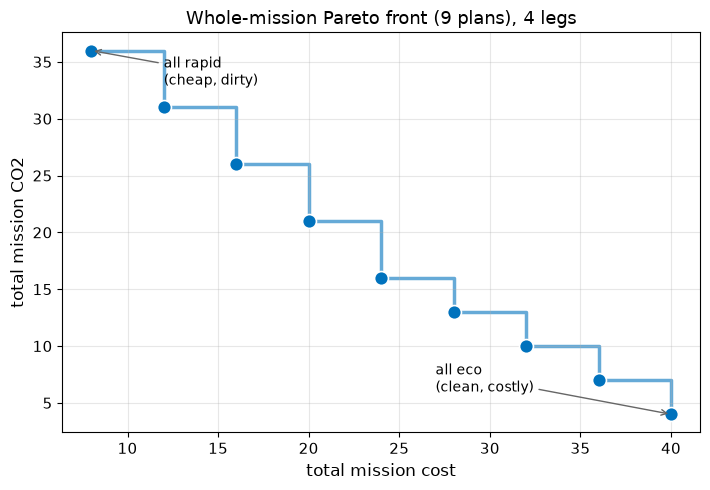

In [4]:
import matplotlib.pyplot as plt

BLUE = "#0072BD"
xs = [c for c, e in front]
ys = [e for c, e in front]

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.step(xs, ys, where="post", color=BLUE, lw=2.5, alpha=0.6, zorder=1)
ax.plot(xs, ys, "o", color=BLUE, markersize=10, zorder=3,
        markeredgecolor="white", markeredgewidth=1.2)
ax.annotate("all rapid\n(cheap, dirty)", xy=(xs[0], ys[0]),
            xytext=(xs[0] + 4, ys[0] - 3), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="0.4"))
ax.annotate("all eco\n(clean, costly)", xy=(xs[-1], ys[-1]),
            xytext=(xs[-1] - 13, ys[-1] + 2), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="0.4"))
ax.set_xlabel("total mission cost", fontsize=12)
ax.set_ylabel("total mission CO2", fontsize=12)
ax.set_title(f"Whole-mission Pareto front ({res.width} plans), {n_legs} legs",
             fontsize=13)
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()


## The front grows polynomially, not exponentially

A worry with antichain-valued DP is that the value front blows up with the horizon. The theory says the front size equals the width of the *reachable frontier*, and for a summed objective on a fixed number of axes it grows polynomially in the horizon. We verify this by sweeping the number of legs and plotting the front width against the raw plan count.


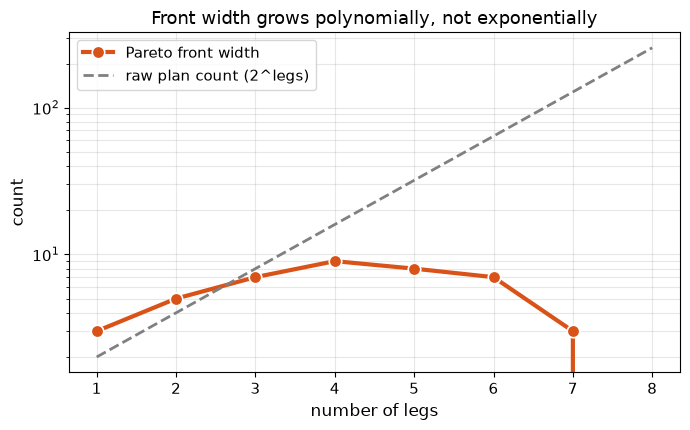

In [5]:
widths = []
legs_range = list(range(1, 9))
for nl in legs_range:
    st = ex20.build_mission(nl)
    g = ex20.StateGrid.linspace(0.0, ex20.ENERGY_CAPACITY, 61)
    r = solve_sequential(st, g, cost_axes=["cost", "co2"],
                         initial_state=ex20.ENERGY_CAPACITY, combine=sum_combine)
    widths.append(r.width)

ORANGE = "#D95319"
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(legs_range, widths, "-o", color=ORANGE, lw=3.0, markersize=9,
        markeredgecolor="white", markeredgewidth=1.2, label="Pareto front width")
ax.plot(legs_range, [2 ** n for n in legs_range], "--", color="0.5", lw=2.0,
        label="raw plan count (2^legs)")
ax.set_xlabel("number of legs", fontsize=12)
ax.set_ylabel("count", fontsize=12)
ax.set_title("Front width grows polynomially, not exponentially", fontsize=13)
ax.set_yscale("log")
ax.legend(fontsize=11, frameon=True, loc="upper left")
ax.grid(True, alpha=0.3, linewidth=0.8, which="both")
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()


## The monotonicity guard

The theory gives two conditions, (H1) and (H2), under which the value front is monotone in the carried state: more energy never shrinks the achievable front. `check_monotonicity` verifies them numerically on the state grid, distinguishing genuinely non-monotone (perishable) stages from the benign consumable-but-monotone case.


In [6]:
rep = check_monotonicity(stages, grid, cost_axes=["cost", "co2"])
print(rep)
print("Value front monotone in carried budget:", rep.monotone_value_guaranteed)


MonotonicityReport(H1=ok, H2=ok, value_monotone=guaranteed)
Value front monotone in carried budget: True


## What the antichain-valued DP delivers

The output is a single object, the whole-mission Pareto front, that a single-objective DP cannot produce: incomparable plans from all-rapid (cheapest, dirtiest) to all-eco (cleanest, costliest), with interior points mixing modes across legs. Every point is on the exact reachable frontier: achievable by some feasible mode sequence, and no achievable non-dominated total is missed.

Two structural facts make this practical rather than a combinatorial explosion. The front width grows polynomially in the horizon (linearly here) rather than as the raw plan count, because cost and CO2 accumulate on two fixed axes. And the value is monotone in the carried budget when (H1) and (H2) hold, which the guard confirms. This is the general sequential co-design object; the scalar rover DP of notebook 19 is its width-one special case.
